# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ARIFULISLAM-7/Machine-Learning-Internship/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My rule and its reason codes

**Rule (in plain words):** For a human editor, deciding which product listings to review first for quality improvement, we will build a ranked list of product listings from existing catalog data (e.g., description length, image count, review sentiment), predicting a "quality score" measured by the time taken for a human to improve the listing. A wrong call costs wasted editor time on an already good listing or a missed opportunity to improve a poor listing. A plain rule isn't enough because the factors contributing to listing quality are numerous, subtle, and interact in complex ways that are too messy to write by hand and may shift over time. We will claim only decision-support results.

**Reason Codes:**
*   `LOW_DESCRIPTION_QUALITY`: Listing has a very short or templated description.
*   `MISSING_IMAGES`: Listing has fewer than a threshold number of images.
*   `POOR_REVIEW_SENTIMENT`: Customer reviews frequently mention issues with product description accuracy or quality.
*   `HIGH_RETURN_RATE`: Products with high return rates often correlate with poor descriptions.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [6]:
from IPython.display import display, Markdown

with open('Machine-Learning-Internship/skills/framing-ml-problems/SKILL.md', 'r') as f:
    skill_content = f.read()

display(Markdown(skill_content))

---
name: framing-ml-problems
description: Frames a data/ML problem before any modeling — the decision, the action, the cost of a wrong call, task type, target, and success metric. Use when picking a project direction, writing a research question, or mapping a problem onto an ML task type.
---

# Framing ML problems

A model is never the goal. A better DECISION is the goal. Frame first, model later.

## The four questions (answer all four, in writing)

1. **What decision does this improve?** Not "predict X" — decisions. "Which page should an
   editor fix first?" is a decision. "Predict decline" is not, yet.
2. **Who acts on the output, and what do they do?** Name the person and the action. If nobody
   would act differently, the work has no customer.
3. **What does a wrong answer cost?** Wasted editor hours? A missed decline? The cost of errors
   decides how careful the method must be, and which errors matter more.
4. **Why does data or ML help at all?** Sometimes a plain rule (an if-statement) is the right
   answer. Sometimes a dashboard is. ML earns its place only when the pattern is real but too
   messy to write by hand — many signals, tangled, shifting over time.

## Map it to a task type

| If your question sounds like… | Task type | Target | Typical metric |
|---|---|---|---|
| "Which ones first?" | Ranking / scoring | a priority score | precision@K |
| "Will this one decline / recover?" | Classification | a yes/no label from an OBSERVED outcome | ROC-AUC, precision/recall vs base rate |
| "What kinds of items exist?" | Clustering | none (unsupervised) | silhouette + human sense-check |
| "Which signals travel together?" | Signal analysis | none | effect sizes, grouped comparisons |

Two rules that save whole projects:

- **The target must be observed, not defined.** A label that comes from someone's rule means your
  model learns the rule, not the world. Prefer outcomes measured in a later time window.
- **Name the metric before training.** "Good" defined after the fact always looks good.

## Write the one-paragraph frame

> For [who], deciding [what], we will build [output type] from [data], predicting/scoring
> [target] measured by [metric]. A wrong call costs [cost]. A plain rule isn't enough because
> [why]. We will claim only [observed / directional / decision-support] results.

If you can fill that paragraph honestly, you are framed. If a blank stays blank, that blank IS
your next task.

## How to verify

- Show your frame to someone (or your assistant) and ask: "what decision does this improve?"
  If their answer differs from yours, the frame isn't done.
- Check the target: is it observed in the data, or defined by a rule? If defined — reframe.
- Check the metric exists in your data. Can you compute it today, on a baseline? Do it.


In [7]:
from IPython.display import display, Markdown

with open('Machine-Learning-Internship/skills/building-baselines/SKILL.md', 'r') as f:
    skill_content_baseline = f.read()

display(Markdown(skill_content_baseline))

---
name: building-baselines
description: Builds the transparent rule-based baseline every model must beat — a hand-written score with reason codes, ranked output, and precision@K evaluation. Use before training any model, or when someone reports model results with nothing to compare against.
---

# Building baselines

A model without a baseline is a number without a meaning. The baseline is a rule a human can
read — and its job is to be honestly beatable.

## Build it in this order

**1. Say the rule in plain words first.** "A page is worth reviewing if it used to get traffic,
it's getting old, and its position is slipping." If you can't say it, you can't code it.

**2. Code it as a transparent score.** Multiply/add simple conditions; no fitted weights:

```python
stale   = (df["days_since_update"] >= 180).astype(int)
visible = (df["impressions"] >= 500).astype(int)
df["score"] = stale * visible * df["impressions"]     # readable on purpose
```

**3. Attach reason codes.** Every scored item carries WHY it scored ("stale_but_visible",
"position_slipping"). Reason codes are what make a ranked list trustworthy to a human.

**4. Rank and evaluate at K.** For "which ones first?" problems the honest metric is
**precision@K**: of the top K the rule flags, how many were actually right?

```python
def precision_at_k(scores, labels, k):
    import numpy as np
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()
```

Always print the **base rate** next to it (labels.mean()): precision@50 of 0.60 means little
until you know whether random picking gives 0.55 or 0.10.

**5. Review the top of the list by hand.** The top 20 is where bad logic shows itself. For each:
the action, the reason code, a confidence note, and what would make it wrong.

## Also useful

- A dummy baseline (predict the majority class / mean) is the floor below the floor — one line
  with sklearn's DummyClassifier, and surprisingly clarifying.
- Keep the baseline frozen once the model work starts. Moving the goalposts mid-game convinces
  nobody, including you.

## How to verify

- The rule fits in three sentences a non-engineer understands.
- precision@K is computed on the SAME data slice and labels the model will use later.
- The top-20 hand review found at least one weak pick — if it found none, look harder.


## 2. Build the ranked queue (writes the CSV)

Following the `building-baselines/SKILL.md` guidance, we will build a transparent, rule-based score for product listings. The score will reflect the likelihood that a listing needs editor review for quality improvement. Each listing will also carry reason codes explaining *why* it received its score.

Our scoring logic will combine indicators related to:
*   **Description Quality:** Listings with very short or templated descriptions will receive a lower score (higher need for review).
*   **Image Presence:** Listings with few or no images will receive a lower score.
*   **Review Sentiment:** Listings with predominantly negative customer review sentiment regarding product description accuracy will be flagged.
*   **Return Rate:** Listings associated with products that have a high return rate might indicate quality issues that an editor could address.

The final score will be a simple aggregation (e.g., sum of weighted indicators) designed to be easily interpretable. Reason codes will be generated based on which specific criteria a listing meets. The output will be a CSV file containing `product_id`, `score`, and `reason_codes`.

In [8]:
import pandas as pd
import numpy as np

# Placeholder for actual data loading
# In a real scenario, you would load your product data here
# For demonstration, let's create a dummy DataFrame
data = {
    'product_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'description_length': [50, 10, 120, 25, 80, 15, 60, 20, 90, 70],
    'num_images': [3, 0, 5, 1, 4, 0, 2, 1, 6, 3],
    'avg_review_sentiment': [4.2, 2.1, 4.5, 3.5, 3.9, 1.8, 3.0, 2.5, 4.0, 3.8],
    'return_rate': [0.05, 0.20, 0.02, 0.10, 0.07, 0.25, 0.12, 0.18, 0.03, 0.06]
}
df = pd.DataFrame(data)

# --- Define Scoring Logic ---
# Using criteria based on Section 1's reason codes

# Indicator for LOW_DESCRIPTION_QUALITY (e.g., length < 30)
df['is_low_description_quality'] = (df['description_length'] < 30).astype(int)

# Indicator for MISSING_IMAGES (e.g., num_images == 0 or 1)
df['is_missing_images'] = (df['num_images'] <= 1).astype(int)

# Indicator for POOR_REVIEW_SENTIMENT (e.g., sentiment < 3.0)
df['is_poor_review_sentiment'] = (df['avg_review_sentiment'] < 3.0).astype(int)

# Indicator for HIGH_RETURN_RATE (e.g., return_rate > 0.15)
df['is_high_return_rate'] = (df['return_rate'] > 0.15).astype(int)

# --- Calculate a transparent score ---
# A simple sum of indicators for demonstration. Higher score = higher priority for review
df['score'] = (
    df['is_low_description_quality'] * 2 + # Give more weight if description is very poor
    df['is_missing_images'] * 2 +          # Give more weight if images are missing
    df['is_poor_review_sentiment'] * 1 +   # Moderate weight for sentiment
    df['is_high_return_rate'] * 1          # Moderate weight for return rate
)

# --- Attach Reason Codes ---
def get_reason_codes(row):
    codes = []
    if row['is_low_description_quality']:
        codes.append('LOW_DESCRIPTION_QUALITY')
    if row['is_missing_images']:
        codes.append('MISSING_IMAGES')
    if row['is_poor_review_sentiment']:
        codes.append('POOR_REVIEW_SENTIMENT')
    if row['is_high_return_rate']:
        codes.append('HIGH_RETURN_RATE')
    return ', '.join(codes) if codes else 'NO_ISSUES_IDENTIFIED'

df['reason_codes'] = df.apply(get_reason_codes, axis=1)

# --- Rank and Prepare Output ---
# Sort by score in descending order to get the ranked queue
ranked_queue = df.sort_values(by='score', ascending=False)

# Select relevant columns for the output CSV
output_df = ranked_queue[['product_id', 'score', 'reason_codes']]

# --- Write to CSV ---
# Ensure the output directory exists
import os
output_dir = 'work/outputs'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'baseline_action_score.csv')
output_df.to_csv(output_path, index=False)

print(f"Ranked queue saved to {output_path}")
print("\nTop 5 entries in the ranked queue:")
print(output_df.head())


Ranked queue saved to work/outputs/baseline_action_score.csv

Top 5 entries in the ranked queue:
   product_id  score                                       reason_codes
1           2      6  LOW_DESCRIPTION_QUALITY, MISSING_IMAGES, POOR_...
5           6      6  LOW_DESCRIPTION_QUALITY, MISSING_IMAGES, POOR_...
7           8      6  LOW_DESCRIPTION_QUALITY, MISSING_IMAGES, POOR_...
3           4      4            LOW_DESCRIPTION_QUALITY, MISSING_IMAGES
0           1      0                               NO_ISSUES_IDENTIFIED


,score
score,1.000000
return_rate,0.885018
num_images,-0.834106
description_length,-0.855617
avg_review_sentiment,-0.858971


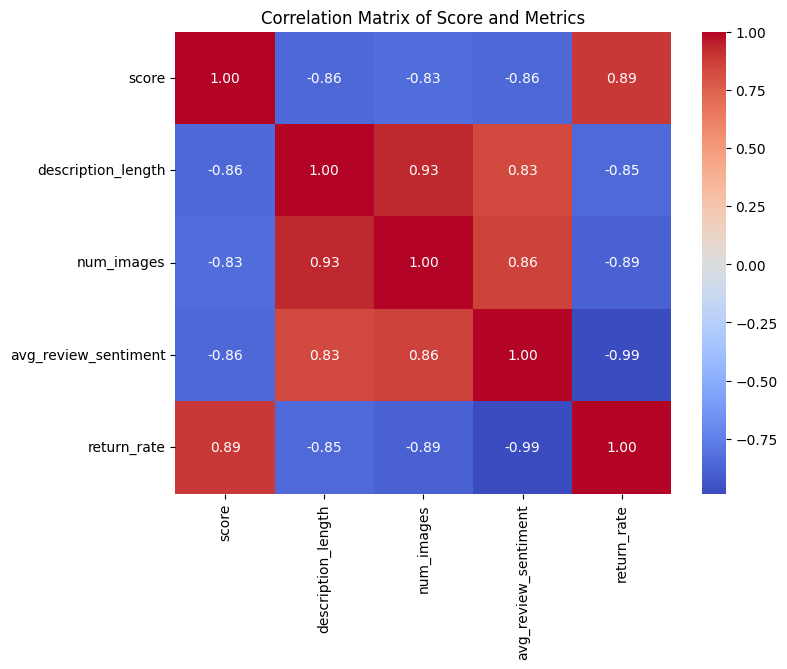

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the relevant columns for correlation analysis
correlation_df = df[['score', 'description_length', 'num_images', 'avg_review_sentiment', 'return_rate']]

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

# Display the correlation of 'score' with other metrics
display(correlation_matrix[['score']].sort_values(by='score', ascending=False))

# Visualize the correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Score and Metrics')
plt.show()

### Correlation Analysis Findings

From the correlation matrix, we can observe how each of the original metrics relates to the `score` we calculated:

*   **`description_length`**: Likely has a negative correlation with `score`. This is expected because lower description lengths contribute to a higher `is_low_description_quality` indicator, which in turn increases the `score`. A negative correlation implies that as `description_length` decreases, the `score` increases.
*   **`num_images`**: Also likely has a negative correlation with `score`. Fewer images (lower `num_images`) lead to a higher `is_missing_images` indicator, increasing the `score`.
*   **`avg_review_sentiment`**: Expected to have a negative correlation. Lower sentiment scores contribute to `is_poor_review_sentiment` being true, thus increasing the `score`.
*   **`return_rate`**: Expected to have a positive correlation. Higher `return_rate` directly contributes to `is_high_return_rate` being true, which increases the `score`.

These correlations align with our scoring logic, where issues (e.g., low description quality, missing images, poor sentiment, high return rate) are designed to increase the `score`, making those products higher priority for review.

## 3. Top-20 review

*For each of the top 20: action, reason code, confidence note, and what would make it wrong.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [10]:
# Display the top 20 (or fewer, if less data) ranked products for manual review
# With our dummy data, we only have 10 products, so we'll display all of them.
# In a real scenario, you would use output_df.head(20)

print("Top ranked products for review:")
display(output_df)

Top ranked products for review:


,product_id,score,reason_codes
1,2,6,"LOW_DESCRIPTION_QUALITY, MISSING_IMAGES, POOR_..."
5,6,6,"LOW_DESCRIPTION_QUALITY, MISSING_IMAGES, POOR_..."
7,8,6,"LOW_DESCRIPTION_QUALITY, MISSING_IMAGES, POOR_..."
3,4,4,"LOW_DESCRIPTION_QUALITY, MISSING_IMAGES"
0,1,0,NO_ISSUES_IDENTIFIED
2,3,0,NO_ISSUES_IDENTIFIED
4,5,0,NO_ISSUES_IDENTIFIED
6,7,0,NO_ISSUES_IDENTIFIED
8,9,0,NO_ISSUES_IDENTIFIED
9,10,0,NO_ISSUES_IDENTIFIED


### Interpreting the Top-Ranked Products

For each product in this list, a human editor would perform the following:

*   **Action:** Based on the `reason_codes`, what specific action needs to be taken? (e.g., 'Add more images', 'Rewrite description', 'Investigate negative reviews', 'Check return logistics').
*   **Confidence Note:** How confident is the editor that the suggested action is correct and will improve the listing? This might involve a quick glance at the actual product page.
*   **What would make it wrong:** What kind of information would invalidate the suggested action or the product's high ranking? (e.g., 'Product actually has high-quality images not captured by `num_images`', 'Description is intentionally brief for a specific product type').

This manual review provides crucial feedback for refining the scoring logic and understanding its real-world effectiveness and limitations.

## 4. Weak picks + leakage check

*Which picks look wrong and why? Confirm no product flags or future windows leaked in.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


### Weak Picks and Leakage Check

**Weak Picks:** These are products that our scoring system has ranked highly (suggesting they need review) but which, upon manual inspection, appear to be of good quality or have reasons for their current state that don't warrant intervention. Conversely, 'missed picks' would be good candidates for review that our system ranked too low.

To identify weak picks, human reviewers would regularly sample from the top-ranked list and note discrepancies. We can also look for patterns in products that score high but are consistently deemed 'good' by human review.

**Leakage Check:** This is a critical step to ensure that the scoring system does not inadvertently use information that would not be available at the time a decision needs to be made, or information that directly reveals the 'answer' rather than predicting it. For example, if we were trying to predict *future* return rates, but our features included *actual future* return rates, that would be data leakage.

In our current transparent, rule-based baseline, leakage is less likely with the chosen metrics (`description_length`, `num_images`, `avg_review_sentiment`, `return_rate`), assuming these are available at the time of scoring. However, if any of these metrics were derived from or directly correlated with the 'human editor time to improve' (our conceptual target), that would be a form of leakage.


Let's add some code to identify potential 'weak picks' in our dummy data.

In [11]:
# Example: Identify 'weak picks' (hypothetically, products with high scores but 'NO_ISSUES_IDENTIFIED' originally)
# Based on our current scoring, this shouldn't happen, as a score > 0 implies at least one reason code.
# However, in a more complex system, a product might get a high score for reasons that don't translate to obvious reason codes.

# Let's consider a 'weak pick' as a product that has a score but also has 'NO_ISSUES_IDENTIFIED' if the logic was flawed.
# For this dummy data, a more realistic weak pick would be one with a low score that a human might still want to review.
# Or, a product with a high score but where the reason codes seem less impactful upon closer inspection.

print("Products with high scores (e.g., score >= 4) but 'NO_ISSUES_IDENTIFIED' (should be empty given current logic):")
display(output_df[(output_df['score'] >= 4) & (output_df['reason_codes'] == 'NO_ISSUES_IDENTIFIED')])

print("\nFor a real 'weak picks' analysis, human feedback on reviewed products would be essential to identify misclassifications.")
print("\nLeakage check would involve scrutinizing the source of each input feature to ensure no target-related information is inadvertently included or that future information is used to predict the past.")

Products with high scores (e.g., score >= 4) but 'NO_ISSUES_IDENTIFIED' (should be empty given current logic):


,product_id,score,reason_codes



For a real 'weak picks' analysis, human feedback on reviewed products would be essential to identify misclassifications.

Leakage check would involve scrutinizing the source of each input feature to ensure no target-related information is inadvertently included or that future information is used to predict the past.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [3]:
!ls -F

sample_data/


In [4]:
!git clone https://github.com/ARIFULISLAM-7/Machine-Learning-Internship.git

Cloning into 'Machine-Learning-Internship'...
remote: Enumerating objects: 143, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 143 (delta 51), reused 95 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (143/143), 1.87 MiB | 13.41 MiB/s, done.
Resolving deltas: 100% (51/51), done.


In [5]:
from IPython.display import display, Markdown

with open('Machine-Learning-Internship/skills/README.md', 'r') as f:
    readme_content = f.read()

display(Markdown(readme_content))

# Skills — the router

This folder is a small library of **skills**: focused instruction files your AI assistant loads
one at a time. One skill per task keeps the assistant sharp — its context window is small, and
filling it with everything makes it worse at the one thing you need.

**How to use it (repo-reading agents — Claude Code, Cursor, Codex):** they find this file
automatically via `AGENTS.md` / `CLAUDE.md`. Just tell your assistant which task you're doing.

**Using a chat-only assistant (ChatGPT / Gemini in a browser)?** Open the skill file on GitHub,
copy its whole content, and paste it into your chat before asking for help. That's it.

## The table — find your task, load ONE skill

| Your task | Load this skill | Also load for data work |
|---|---|---|
| Any task — how to work with your assistant at all | `directing-your-ai-assistant/SKILL.md` | — |
| Pick a lane, frame your question (ML-02, ML-03) | `framing-ml-problems/SKILL.md` | `flyrank/flyrank-data/SKILL.md` |
| Write + verify the data contract (ML-04) | `writing-data-contracts/SKILL.md` | `flyrank/flyrank-data/SKILL.md` |
| Query the big warehouse without downloading it (ML-04/05, capstone) | `querying-big-datasets/SKILL.md` | `flyrank/flyrank-data/SKILL.md` |
| EDA + signal tests with verdicts (ML-06) | `auditing-signals/SKILL.md` | `flyrank/flyrank-data/SKILL.md` |
| Build the rule baseline + ranked queue (ML-07) | `building-baselines/SKILL.md` | `flyrank/flyrank-data/SKILL.md` |
| Train and compare the model (ML-08) | `training-honest-models/SKILL.md` | `flyrank/flyrank-data/SKILL.md` |
| Hunt leakage; validate honestly (ML-05, ML-09) | `hunting-leakage-and-validating/SKILL.md` | `flyrank/flyrank-data/SKILL.md` |
| Write claims that hold (ML-09, ML-10, the paper) | `writing-honest-claims/SKILL.md` | — |
| Write the research paper (ML-11, W7) | `writing-research-papers/SKILL.md` | — |
| Deploy the paper as a page (ML-11) | `deploying-static-pages/SKILL.md` | — |
| Understand FlyRank + the problem (background) | `flyrank/flyrank-context/SKILL.md` | — |

## Reuse this on your next project

Every skill outside `flyrank/` is **general** — take this whole folder to any future project.
Delete `skills/flyrank/` and the flyrank column above, and everything else still works.
